In [69]:
from detectron2.config import get_cfg
from detectron2.projects.deeplab import add_deeplab_config
from mask2former import add_maskformer2_config

In [70]:
cfg = get_cfg()
add_deeplab_config(cfg)
add_maskformer2_config(cfg)

#cfg.merge_from_file('configs/swin/maskformer2_swin_base_384_bs16_50ep.yaml')
cfg.merge_from_file('configs/instance_segmentation/maskformer2_R50_bs16_50ep.yaml')
cfg.MODEL.RESNETS.NORM = "BN"
#cfg.MODEL.WEIGHTS = 'https://dl.fbaipublicfiles.com/maskformer/mask2former/coco/panoptic/maskformer2_swin_large_IN21k_384_bs16_100ep/model_final_f07440.pkl'
#cfg.MODEL.WEIGHTS = 'https://dl.fbaipublicfiles.com/maskformer/mask2former/coco/instance/maskformer2_swin_base_384_bs16_50ep/model_final_f6e0f6.pkl'
#cfg.MODEL.WEIGHTS = 'https://dl.fbaipublicfiles.com/maskformer/mask2former/coco/panoptic/maskformer2_R50_bs16_50ep/model_final_94dc52.pkl'
#cfg.MODEL.WEIGHTS = 'https://dl.fbaipublicfiles.com/maskformer/mask2former/coco/instance/maskformer2_R50_bs16_50ep/model_final_3c8ec9.pkl'
#cfg.MODEL.WEIGHTS = './elasticdepthresnet_ckpt.pth'
#cfg.MODEL.WEIGHTS = './fullelasticm2f_ckpt.pth'
cfg.MODEL.WEIGHTS = './fullelasticm2f_ckpt.pth'
cfg.OUTPUT_DIR = "./test_output2/"

In [71]:
print(cfg)

CUDNN_BENCHMARK: False
DATALOADER:
  ASPECT_RATIO_GROUPING: True
  FILTER_EMPTY_ANNOTATIONS: True
  NUM_WORKERS: 4
  REPEAT_THRESHOLD: 0.0
  SAMPLER_TRAIN: TrainingSampler
DATASETS:
  PRECOMPUTED_PROPOSAL_TOPK_TEST: 1000
  PRECOMPUTED_PROPOSAL_TOPK_TRAIN: 2000
  PROPOSAL_FILES_TEST: ()
  PROPOSAL_FILES_TRAIN: ()
  TEST: ('coco_2017_val',)
  TRAIN: ('coco_2017_train',)
GLOBAL:
  HACK: 1.0
INPUT:
  COLOR_AUG_SSD: False
  CROP:
    ENABLED: False
    SINGLE_CATEGORY_MAX_AREA: 1.0
    SIZE: [0.9, 0.9]
    TYPE: relative_range
  DATASET_MAPPER_NAME: coco_instance_lsj
  FORMAT: RGB
  IMAGE_SIZE: 1024
  MASK_FORMAT: polygon
  MAX_SCALE: 2.0
  MAX_SIZE_TEST: 1333
  MAX_SIZE_TRAIN: 1333
  MIN_SCALE: 0.1
  MIN_SIZE_TEST: 800
  MIN_SIZE_TRAIN: (800,)
  MIN_SIZE_TRAIN_SAMPLING: choice
  RANDOM_FLIP: horizontal
  SIZE_DIVISIBILITY: -1
MODEL:
  ANCHOR_GENERATOR:
    ANGLES: [[-90, 0, 90]]
    ASPECT_RATIOS: [[0.5, 1.0, 2.0]]
    NAME: DefaultAnchorGenerator
    OFFSET: 0.0
    SIZES: [[32, 64, 128, 

In [72]:
cfg.freeze()

In [73]:
from detectron2.engine import (
    DefaultWSTrainer,
)
class Trainer(DefaultWSTrainer):
    """
    Extension of the Trainer class adapted to MaskFormer.
    """

    @classmethod
    def build_evaluator(cls, cfg, dataset_name, output_folder=None):
        """
        Create evaluator(s) for a given dataset.
        This uses the special metadata "evaluator_type" associated with each
        builtin dataset. For your own dataset, you can simply create an
        evaluator manually in your script and do not have to worry about the
        hacky if-else logic here.
        """
        if output_folder is None:
            output_folder = os.path.join(cfg.OUTPUT_DIR, "inference")
        evaluator_list = []
        evaluator_type = MetadataCatalog.get(dataset_name).evaluator_type
        # semantic segmentation
        if evaluator_type in ["sem_seg", "ade20k_panoptic_seg"]:
            evaluator_list.append(
                SemSegEvaluator(
                    dataset_name,
                    distributed=True,
                    output_dir=output_folder,
                )
            )
        # instance segmentation
        if evaluator_type == "coco":
            evaluator_list.append(COCOEvaluator(dataset_name, output_dir=output_folder))
        # panoptic segmentation
        if evaluator_type in [
            "coco_panoptic_seg",
            "ade20k_panoptic_seg",
            "cityscapes_panoptic_seg",
            "mapillary_vistas_panoptic_seg",
        ]:
            if cfg.MODEL.MASK_FORMER.TEST.PANOPTIC_ON:
                evaluator_list.append(COCOPanopticEvaluator(dataset_name, output_folder))
        # COCO
        if evaluator_type == "coco_panoptic_seg" and cfg.MODEL.MASK_FORMER.TEST.INSTANCE_ON:
            evaluator_list.append(COCOEvaluator(dataset_name, output_dir=output_folder))
        if evaluator_type == "coco_panoptic_seg" and cfg.MODEL.MASK_FORMER.TEST.SEMANTIC_ON:
            evaluator_list.append(SemSegEvaluator(dataset_name, distributed=True, output_dir=output_folder))
        # Mapillary Vistas
        if evaluator_type == "mapillary_vistas_panoptic_seg" and cfg.MODEL.MASK_FORMER.TEST.INSTANCE_ON:
            evaluator_list.append(InstanceSegEvaluator(dataset_name, output_dir=output_folder))
        if evaluator_type == "mapillary_vistas_panoptic_seg" and cfg.MODEL.MASK_FORMER.TEST.SEMANTIC_ON:
            evaluator_list.append(SemSegEvaluator(dataset_name, distributed=True, output_dir=output_folder))
        # Cityscapes
        if evaluator_type == "cityscapes_instance":
            assert (
                torch.cuda.device_count() > comm.get_rank()
            ), "CityscapesEvaluator currently do not work with multiple machines."
            return CityscapesInstanceEvaluator(dataset_name)
        if evaluator_type == "cityscapes_sem_seg":
            assert (
                torch.cuda.device_count() > comm.get_rank()
            ), "CityscapesEvaluator currently do not work with multiple machines."
            return CityscapesSemSegEvaluator(dataset_name)
        if evaluator_type == "cityscapes_panoptic_seg":
            if cfg.MODEL.MASK_FORMER.TEST.SEMANTIC_ON:
                assert (
                    torch.cuda.device_count() > comm.get_rank()
                ), "CityscapesEvaluator currently do not work with multiple machines."
                evaluator_list.append(CityscapesSemSegEvaluator(dataset_name))
            if cfg.MODEL.MASK_FORMER.TEST.INSTANCE_ON:
                assert (
                    torch.cuda.device_count() > comm.get_rank()
                ), "CityscapesEvaluator currently do not work with multiple machines."
                evaluator_list.append(CityscapesInstanceEvaluator(dataset_name))
        # ADE20K
        if evaluator_type == "ade20k_panoptic_seg" and cfg.MODEL.MASK_FORMER.TEST.INSTANCE_ON:
            evaluator_list.append(InstanceSegEvaluator(dataset_name, output_dir=output_folder))
        # LVIS
        if evaluator_type == "lvis":
            return LVISEvaluator(dataset_name, output_dir=output_folder)
        if len(evaluator_list) == 0:
            raise NotImplementedError(
                "no Evaluator for the dataset {} with the type {}".format(
                    dataset_name, evaluator_type
                )
            )
        elif len(evaluator_list) == 1:
            return evaluator_list[0]
        return DatasetEvaluators(evaluator_list)

    @classmethod
    def build_train_loader(cls, cfg):
        # Semantic segmentation dataset mapper
        if cfg.INPUT.DATASET_MAPPER_NAME == "mask_former_semantic":
            mapper = MaskFormerSemanticDatasetMapper(cfg, True)
            return build_detection_train_loader(cfg, mapper=mapper)
        # Panoptic segmentation dataset mapper
        elif cfg.INPUT.DATASET_MAPPER_NAME == "mask_former_panoptic":
            mapper = MaskFormerPanopticDatasetMapper(cfg, True)
            return build_detection_train_loader(cfg, mapper=mapper)
        # Instance segmentation dataset mapper
        elif cfg.INPUT.DATASET_MAPPER_NAME == "mask_former_instance":
            mapper = MaskFormerInstanceDatasetMapper(cfg, True)
            return build_detection_train_loader(cfg, mapper=mapper)
        # coco instance segmentation lsj new baseline
        elif cfg.INPUT.DATASET_MAPPER_NAME == "coco_instance_lsj":
            mapper = COCOInstanceNewBaselineDatasetMapper(cfg, True)
            return build_detection_train_loader(cfg, mapper=mapper)
        # coco panoptic segmentation lsj new baseline
        elif cfg.INPUT.DATASET_MAPPER_NAME == "coco_panoptic_lsj":
            mapper = COCOPanopticNewBaselineDatasetMapper(cfg, True)
            return build_detection_train_loader(cfg, mapper=mapper)
        else:
            mapper = None
            return build_detection_train_loader(cfg, mapper=mapper)

    @classmethod
    def build_lr_scheduler(cls, cfg, optimizer):
        """
        It now calls :func:`detectron2.solver.build_lr_scheduler`.
        Overwrite it if you'd like a different scheduler.
        """
        return build_lr_scheduler(cfg, optimizer)

    @classmethod
    def build_optimizer(cls, cfg, model):
        weight_decay_norm = cfg.SOLVER.WEIGHT_DECAY_NORM
        weight_decay_embed = cfg.SOLVER.WEIGHT_DECAY_EMBED

        defaults = {}
        defaults["lr"] = cfg.SOLVER.BASE_LR
        defaults["weight_decay"] = cfg.SOLVER.WEIGHT_DECAY

        norm_module_types = (
            torch.nn.BatchNorm1d,
            torch.nn.BatchNorm2d,
            torch.nn.BatchNorm3d,
            torch.nn.SyncBatchNorm,
            # NaiveSyncBatchNorm inherits from BatchNorm2d
            torch.nn.GroupNorm,
            torch.nn.InstanceNorm1d,
            torch.nn.InstanceNorm2d,
            torch.nn.InstanceNorm3d,
            torch.nn.LayerNorm,
            torch.nn.LocalResponseNorm,
        )

        params: List[Dict[str, Any]] = []
        memo: Set[torch.nn.parameter.Parameter] = set()
        for module_name, module in model.named_modules():
            for module_param_name, value in module.named_parameters(recurse=False):
                if not value.requires_grad:
                    continue
                # Avoid duplicating parameters
                if value in memo:
                    continue
                memo.add(value)

                hyperparams = copy.copy(defaults)
                if "backbone" in module_name:
                    hyperparams["lr"] = hyperparams["lr"] * cfg.SOLVER.BACKBONE_MULTIPLIER
                if (
                    "relative_position_bias_table" in module_param_name
                    or "absolute_pos_embed" in module_param_name
                ):
                    print(module_param_name)
                    hyperparams["weight_decay"] = 0.0
                if isinstance(module, norm_module_types):
                    hyperparams["weight_decay"] = weight_decay_norm
                if isinstance(module, torch.nn.Embedding):
                    hyperparams["weight_decay"] = weight_decay_embed
                params.append({"params": [value], **hyperparams})

        def maybe_add_full_model_gradient_clipping(optim):
            # detectron2 doesn't have full model gradient clipping now
            clip_norm_val = cfg.SOLVER.CLIP_GRADIENTS.CLIP_VALUE
            enable = (
                cfg.SOLVER.CLIP_GRADIENTS.ENABLED
                and cfg.SOLVER.CLIP_GRADIENTS.CLIP_TYPE == "full_model"
                and clip_norm_val > 0.0
            )

            class FullModelGradientClippingOptimizer(optim):
                def step(self, closure=None):
                    all_params = itertools.chain(*[x["params"] for x in self.param_groups])
                    torch.nn.utils.clip_grad_norm_(all_params, clip_norm_val)
                    super().step(closure=closure)

            return FullModelGradientClippingOptimizer if enable else optim

        optimizer_type = cfg.SOLVER.OPTIMIZER
        if optimizer_type == "SGD":
            optimizer = maybe_add_full_model_gradient_clipping(torch.optim.SGD)(
                params, cfg.SOLVER.BASE_LR, momentum=cfg.SOLVER.MOMENTUM
            )
        elif optimizer_type == "ADAMW":
            optimizer = maybe_add_full_model_gradient_clipping(torch.optim.AdamW)(
                params, cfg.SOLVER.BASE_LR
            )
        else:
            raise NotImplementedError(f"no optimizer type {optimizer_type}")
        if not cfg.SOLVER.CLIP_GRADIENTS.CLIP_TYPE == "full_model":
            optimizer = maybe_add_gradient_clipping(cfg, optimizer)
        return optimizer

    @classmethod
    def test_with_TTA(cls, cfg, model):
        logger = logging.getLogger("detectron2.trainer")
        # In the end of training, run an evaluation with TTA.
        logger.info("Running inference with test-time augmentation ...")
        model = SemanticSegmentorWithTTA(cfg, model)
        evaluators = [
            cls.build_evaluator(
                cfg, name, output_folder=os.path.join(cfg.OUTPUT_DIR, "inference_TTA")
            )
            for name in cfg.DATASETS.TEST
        ]
        res = cls.test(cfg, model, evaluators)
        res = OrderedDict({k + "_TTA": v for k, v in res.items()})
        return res

In [74]:
import torch
import copy
from detectron2.evaluation import (
    CityscapesInstanceEvaluator,
    CityscapesSemSegEvaluator,
    COCOEvaluator,
    COCOPanopticEvaluator,
    DatasetEvaluators,
    LVISEvaluator,
    SemSegEvaluator,
    verify_results,
)
from mask2former import (
    COCOInstanceNewBaselineDatasetMapper,
    COCOPanopticNewBaselineDatasetMapper,
    InstanceSegEvaluator,
    MaskFormerInstanceDatasetMapper,
    MaskFormerPanopticDatasetMapper,
    MaskFormerSemanticDatasetMapper,
    SemanticSegmentorWithTTA,
    add_maskformer2_config,
)
from detectron2.data import MetadataCatalog, build_detection_train_loader
from detectron2.projects.deeplab import build_lr_scheduler



In [75]:
print(cfg.OUTPUT_DIR)
print(cfg.MODEL.WEIGHTS)
#print(cfg.MODEL.WEIGHTS)


./test_output2/
./fullelasticm2f_ckpt.pth


In [96]:
import cv2
im = cv2.imread("./planetopview1.png")
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

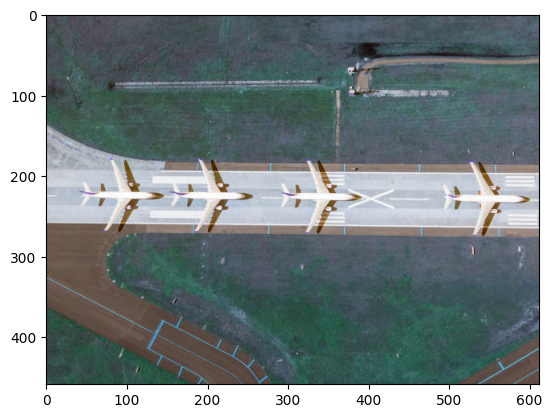

In [97]:
plt.imshow(im)

In [85]:
from detectron2.engine import DefaultPredictor
predictor = DefaultPredictor(cfg)
predictor.model.set_max_net()

#predictor.model.backbone.set_active_subnet([1,1,1,1])
outputs = predictor(im)

[01/06 04:40:11 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from ./fullelasticm2f_ckpt.pth ...


Some model parameters or buffers are not found in the checkpoint:
backbone.res2.0.conv1.norm.num_batches_tracked
backbone.res2.0.conv2.norm.num_batches_tracked
backbone.res2.0.conv3.norm.num_batches_tracked
backbone.res2.0.shortcut.norm.num_batches_tracked
backbone.res2.1.conv1.norm.num_batches_tracked
backbone.res2.1.conv2.norm.num_batches_tracked
backbone.res2.1.conv3.norm.num_batches_tracked
backbone.res2.2.conv1.norm.num_batches_tracked
backbone.res2.2.conv2.norm.num_batches_tracked
backbone.res2.2.conv3.norm.num_batches_tracked
backbone.res3.0.conv1.norm.num_batches_tracked
backbone.res3.0.conv2.norm.num_batches_tracked
backbone.res3.0.conv3.norm.num_batches_tracked
backbone.res3.0.shortcut.norm.num_batches_tracked
backbone.res3.1.conv1.norm.num_batches_tracked
backbone.res3.1.conv2.norm.num_batches_tracked
backbone.res3.1.conv3.norm.num_batches_tracked
backbone.res3.2.conv1.norm.num_batches_tracked
backbone.res3.2.conv2.norm.num_batches_tracked
backbone.res3.2.conv3.norm.num_batc

In [86]:
!pwd
#print(predictor.model.backbone.layers)
all_keys = predictor.model.backbone.state_dict().keys()
#print(all_keys)
#print("layers.0.blocks.0.attn.relative_position_bias_table" in all_keys)
#print(predictor.model.backbone.layers[2].downsample)
#print(type(predictor.model.backbone.state_dict()))
#print(predictor.model.backbone.layers[2].blocks[0].attn.relative_position_bias_table.shape)
#'layers.2.blocks.0.attn.qkv.weight'
#print(predictor.model.backbone.layers[2].blocks.state_dict().keys())
#print(predictor.model)

/home/akhare39/animesh/wsobjdet


In [87]:
#torch.save(predictor.model.backbone, "ckpts/COCO_M2F_SWIN_B_InstanceSeg.pt")

In [88]:
#torch.save({"model":predictor.model.backbone.state_dict()}, "ckpts/COCO_M2F_SWIN_B_InstanceSeg_state_dict.pth")

Panoptic segmentation (top), instance segmentation (middle), semantic segmentation (bottom)
(550, 734, 3)


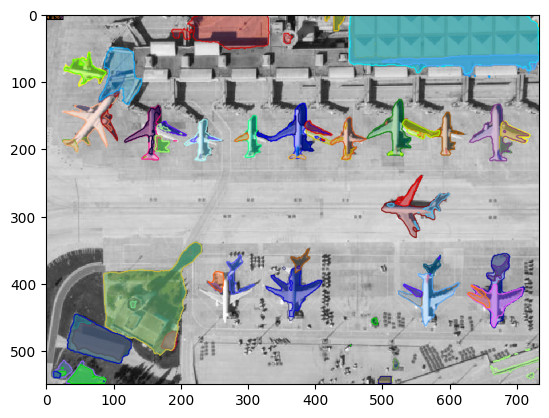

In [89]:
from detectron2.utils.visualizer import Visualizer, ColorMode
from detectron2.data import MetadataCatalog
import numpy as np

coco_metadata = MetadataCatalog.get("coco_2017_val_instance")

# Show panoptic/instance/semantic predictions: 
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
#panoptic_result = v.draw_panoptic_seg(outputs["panoptic_seg"][0].to("cpu"), outputs["panoptic_seg"][1]).get_image()
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
instance_result = v.draw_instance_predictions(outputs["instances"].to("cpu")).get_image()
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
#semantic_result = v.draw_sem_seg(outputs["sem_seg"].argmax(0).to("cpu")).get_image()
print("Panoptic segmentation (top), instance segmentation (middle), semantic segmentation (bottom)")
print(instance_result.shape)
plt.imshow(instance_result)

In [90]:
#!wget http://images.cocodataset.org/val2017/000000001584.jpg -q -O input.jpg
!wget http://images.cocodataset.org/val2017/000000005477.jpg -q -O input.jpg
im = cv2.imread("./input.jpg")


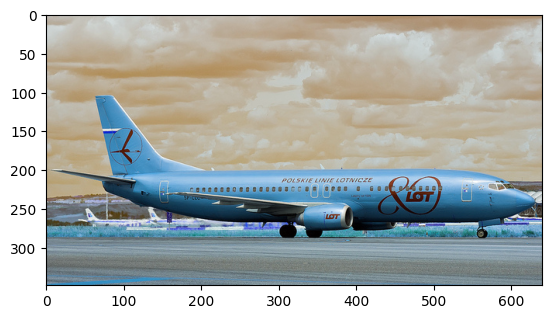

In [91]:
plt.imshow(im)

In [92]:
from detectron2.engine import DefaultPredictor
predictor = DefaultPredictor(cfg)
#predictor.model.backbone.set_active_subnet([0, 1, 3, 0])
outputs = predictor(im)


[01/06 04:40:15 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from ./fullelasticm2f_ckpt.pth ...


Some model parameters or buffers are not found in the checkpoint:
backbone.res2.0.conv1.norm.num_batches_tracked
backbone.res2.0.conv2.norm.num_batches_tracked
backbone.res2.0.conv3.norm.num_batches_tracked
backbone.res2.0.shortcut.norm.num_batches_tracked
backbone.res2.1.conv1.norm.num_batches_tracked
backbone.res2.1.conv2.norm.num_batches_tracked
backbone.res2.1.conv3.norm.num_batches_tracked
backbone.res2.2.conv1.norm.num_batches_tracked
backbone.res2.2.conv2.norm.num_batches_tracked
backbone.res2.2.conv3.norm.num_batches_tracked
backbone.res3.0.conv1.norm.num_batches_tracked
backbone.res3.0.conv2.norm.num_batches_tracked
backbone.res3.0.conv3.norm.num_batches_tracked
backbone.res3.0.shortcut.norm.num_batches_tracked
backbone.res3.1.conv1.norm.num_batches_tracked
backbone.res3.1.conv2.norm.num_batches_tracked
backbone.res3.1.conv3.norm.num_batches_tracked
backbone.res3.2.conv1.norm.num_batches_tracked
backbone.res3.2.conv2.norm.num_batches_tracked
backbone.res3.2.conv3.norm.num_batc

In [93]:
#print(outputs)

Panoptic segmentation (top), instance segmentation (middle), semantic segmentation (bottom)
(418, 768, 3)


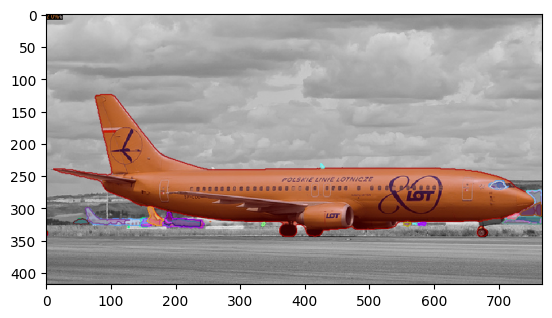

In [95]:
from detectron2.utils.visualizer import Visualizer, ColorMode
from detectron2.data import MetadataCatalog
import numpy as np

coco_metadata = MetadataCatalog.get("coco_2017_val_instance")

# Show panoptic/instance/semantic predictions: 
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
#panoptic_result = v.draw_panoptic_seg(outputs["panoptic_seg"][0].to("cpu"), outputs["panoptic_seg"][1]).get_image()
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
instance_result = v.draw_instance_predictions(outputs["instances"].to("cpu")).get_image()
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
#semantic_result = v.draw_sem_seg(outputs["sem_seg"].argmax(0).to("cpu")).get_image()
print("Panoptic segmentation (top), instance segmentation (middle), semantic segmentation (bottom)")
print(instance_result.shape)
plt.imshow(instance_result)

In [24]:
trainer = Trainer(cfg)

[01/05 18:28:17 d2.engine.defaults]: Model:
MaskFormer(
  (backbone): ResNet(
    (stem): BasicStem(
      (conv1): Conv2d(
        3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
        (norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (res2): Sequential(
      (0): BottleneckBlock(
        (shortcut): Conv2d(
          64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False
          (norm): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (conv1): Conv2d(
          64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False
          (norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (conv2): Conv2d(
          64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False
          (norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (conv3): Conv2d(


[01/05 18:28:30 d2.data.datasets.coco]: Loading datasets/coco/annotations/instances_train2017.json takes 12.64 seconds.
[01/05 18:28:30 d2.data.datasets.coco]: Loaded 118287 images in COCO format from datasets/coco/annotations/instances_train2017.json
[01/05 18:28:37 d2.data.build]: Removed 1021 images with no usable annotations. 117266 images left.
[01/05 18:28:40 d2.data.build]: Distribution of instances among all 80 categories:
|   category    | #instances   |   category   | #instances   |   category    | #instances   |
|:-------------:|:-------------|:------------:|:-------------|:-------------:|:-------------|
|    person     | 257253       |   bicycle    | 7056         |      car      | 43533        |
|  motorcycle   | 8654         |   airplane   | 5129         |      bus      | 6061         |
|     train     | 4570         |    truck     | 9970         |     boat      | 10576        |
| traffic light | 12842        | fire hydrant | 1865         |   stop sign   | 1983         |
|

In [25]:
import os
from detectron2.checkpoint import DetectionCheckpointer

model = Trainer.build_model(cfg)
print(model.backbone.stem.conv1.weight[0, 0, 0, :])
DetectionCheckpointer(model, save_dir=cfg.OUTPUT_DIR).resume_or_load(
    cfg.MODEL.WEIGHTS, resume=True
)
print(model.backbone.stem.conv1.weight[0, 0, 0, :])

[01/05 18:28:44 d2.engine.defaults]: Model:
MaskFormer(
  (backbone): ResNet(
    (stem): BasicStem(
      (conv1): Conv2d(
        3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
        (norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (res2): Sequential(
      (0): BottleneckBlock(
        (shortcut): Conv2d(
          64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False
          (norm): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (conv1): Conv2d(
          64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False
          (norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (conv2): Conv2d(
          64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False
          (norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (conv3): Conv2d(


tensor([ 0.0424, -0.0085,  0.0194,  0.0017,  0.0014,  0.0074,  0.0059],
       device='cuda:0', grad_fn=<SliceBackward0>)
[01/05 18:28:44 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from ./baseckpt_fintune_output/model_0249999.pth ...


/home/akhare39/miniconda3/lib/python3.9/site-packages/fvcore/common/checkpoint.py:252: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(f, map_location=torch.

tensor([ 0.0108,  0.0101, -0.0145, -0.0206, -0.0329, -0.0323, -0.0519],
       device='cuda:0', grad_fn=<SliceBackward0>)


In [26]:
#print(model.backbone.stem.conv1.norm.weight)

In [27]:
import copy
import torch.nn.functional as F
import torch.nn as nn
import random
import torch


class AverageMeter(object):
    """
    Computes and stores the average and current value
    Copied from: https://github.com/pytorch/examples/blob/master/imagenet/main.py
    """

    def __init__(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

#both group norm and batch norm updated
def set_running_statistics(model, data_loader):
    bn_mean = {}
    bn_var = {}

    gn_mean = {}
    gn_var = {}
    
    forward_model = copy.deepcopy(model)
    for name, m in forward_model.named_modules():
        if isinstance(m, nn.BatchNorm2d):
            bn_mean[name] = AverageMeter()
            bn_var[name] = AverageMeter()

            def new_forward(bn, mean_est, var_est):
                def lambda_forward(x):
                    batch_mean = (
                        x.mean(0, keepdim=True)
                        .mean(2, keepdim=True)
                        .mean(3, keepdim=True)
                    )  # 1, C, 1, 1
                    batch_var = (x - batch_mean) * (x - batch_mean)
                    batch_var = (
                        batch_var.mean(0, keepdim=True)
                        .mean(2, keepdim=True)
                        .mean(3, keepdim=True)
                    )

                    batch_mean = torch.squeeze(batch_mean)
                    batch_var = torch.squeeze(batch_var)

                    mean_est.update(batch_mean.data, x.size(0))
                    var_est.update(batch_var.data, x.size(0))

                    # bn forward using calculated mean & var
                    _feature_dim = batch_mean.size(0)
                    return F.batch_norm(
                        x,
                        batch_mean,
                        batch_var,
                        bn.weight[:_feature_dim],
                        bn.bias[:_feature_dim],
                        False,
                        0.0,
                        bn.eps,
                    )

                return lambda_forward

            m.forward = new_forward(m, bn_mean[name], bn_var[name])
    
    if len(bn_mean) == 0:
        # skip if there is no batch normalization layers in the network
        return

    with torch.no_grad():
        count = 1
        #DynamicBatchNorm2d.SET_RUNNING_STATISTICS = True
        for input_images in data_loader:
            forward_model(input_images)
            count+=1
            if count >= 2500:
                break
            if count % 50 == 0:
                print(count)
        #DynamicBatchNorm2d.SET_RUNNING_STATISTICS = False

    for name, m in model.named_modules():
        if name in bn_mean and bn_mean[name].count > 0:
            feature_dim = bn_mean[name].avg.size(0)
            assert isinstance(m, nn.BatchNorm2d)
            m.running_mean.data[:feature_dim].copy_(bn_mean[name].avg)
            m.running_var.data[:feature_dim].copy_(bn_var[name].avg)

In [28]:
def count_parameters(model, check_grad=False):
    count = 0
    for name, parameter in model.named_parameters():
        #print(name)
        if not check_grad or (check_grad and parameter.requires_grad):
            count += parameter.numel()
    return count

In [29]:
total_num_param = count_parameters(model)
print("total params", total_num_param)
          
def maskformertransformer_param_count_helper(name, param, pixel_decoder_depth, transformer_decoder_depth):
    max_pixel_depth = 6+(pixel_decoder_depth-2)-1
    max_transformer_depth = 9+(transformer_decoder_depth-2)-1
    if 'predictor' in name:
        if 'transformer_self_attention_layers' in name or 'transformer_cross_attention_layers' in name \
            or 'transformer_ffn_layers' in name:
            if int(name.split('.')[3]) <= max_transformer_depth:
                #print(name, int(name.split('.')[3]))
                return param.numel()
            else:
                return 0            
    elif 'pixel_decoder.transformer.encoder.layers' in name:
        if int(name.split('.')[5]) <= max_pixel_depth:
            #print(name, int(name.split('.')[5]))
            return param.numel()
        else:
            return 0
    return param.numel()
          
def count_parameters_small(model, pixel_decoder_depth=2, transformer_decoder_depth=2, check_grad=False):
    count = 0
    for name, parameter in model.named_parameters():
        if 'backbone' in name and 'res2' in name:
            if '0' in name and parameter.requires_grad:
                #print(name)
                count += parameter.numel()
        elif 'backbone' in name and 'res3' in name:
            if ('0' in name or '.1.' in name) and parameter.requires_grad:
                #print(name)
                count += parameter.numel()
        elif 'backbone' in name and 'res4' in name:
            if ('0' in name or '.1.' in name or '.2.' in name or '.3.' in name) and parameter.requires_grad:
                #print(name)
                count += parameter.numel()
        elif 'backbone' in name and 'res5' in name:
            if '0' in name and parameter.requires_grad:
                #print(name)
                count += parameter.numel()
        elif not check_grad or (check_grad and parameter.requires_grad):
            count += maskformertransformer_param_count_helper(name, parameter, pixel_decoder_depth, \
                transformer_decoder_depth)
    return count

def count_parameters_large(model, pixel_decoder_depth=2, transformer_decoder_depth=2, check_grad=False):
    count = 0
    for name, parameter in model.named_parameters():
        if not check_grad or (check_grad and parameter.requires_grad):
            count += maskformertransformer_param_count_helper(name, parameter, pixel_decoder_depth, \
                transformer_decoder_depth)
    return count

smallest_net_param = count_parameters_small(model, 0, 0)
print("smallest net params:", smallest_net_param)
print("precentage of total:", smallest_net_param/total_num_param)
print("percentage decrease:", (total_num_param-smallest_net_param)/total_num_param)
def count_parameters_middle(model, pixel_decoder_depth=2, transformer_decoder_depth=2, check_grad=False):
    count = 0
    for name, parameter in model.named_parameters():
        if 'backbone' in name and 'res2' in name:
            if ('0' in name or '.1.' in name) and parameter.requires_grad:
                #print(name)
                count += parameter.numel()
        elif 'backbone' in name and 'res3' in name:
            if ('0' in name or '.1.' in name or '.2.' in name) and parameter.requires_grad:
                #print(name)
                count += parameter.numel()
        elif 'backbone' in name and 'res4' in name:
            if ('0' in name or '.1.' in name or '.2.' in name or '.3.' in name or '.4.' in name) and parameter.requires_grad:
                #print(name)
                count += parameter.numel()
        elif 'backbone' in name and 'res5' in name:
            if ('0' in name or '.1.' in name) and parameter.requires_grad:
                #print(name)
                count += parameter.numel()
        elif not check_grad or (check_grad and parameter.requires_grad):
            count += maskformertransformer_param_count_helper(name, parameter, pixel_decoder_depth, \
                transformer_decoder_depth)
    return count

middle_net_param = count_parameters_middle(model, 1, 1)
print("number of param in middle network:", middle_net_param)

smallest_backbone_param = count_parameters_small(model, 2, 2)
print("smallest backbone net params:", smallest_backbone_param)

middle_backbone_param = count_parameters_middle(model, 2, 2)
print("middle backbone net params:", middle_backbone_param)

smallest_pixel_decoder_max_rest_param = count_parameters_large(model, 0, 2)
print("max backbone, min pixel decoder, max transformer decoder net params:", smallest_pixel_decoder_max_rest_param)

smallest_transformer_decoder_max_rest_param = count_parameters_large(model, 2, 0)
print("max backbone, max pixel decoder, min transformer decoder net params:", smallest_transformer_decoder_max_rest_param)

middle_backbone_min_tf_decoder_param = count_parameters_middle(model, 2, 1)
print("middle backbone, max pixel decoder, min transformer decoder net params:", middle_backbone_min_tf_decoder_param)

total params 44023377
smallest net params: 27541009
precentage of total: 0.6255996444797953
percentage decrease: 0.3744003555202046
number of param in middle network: 35782193
smallest backbone net params: 32162897
middle backbone net params: 38093137
max backbone, min pixel decoder, max transformer decoder net params: 42558993
max backbone, max pixel decoder, min transformer decoder net params: 40865873
middle backbone, max pixel decoder, min transformer decoder net params: 36514385


In [30]:
print(model)

MaskFormer(
  (backbone): ResNet(
    (stem): BasicStem(
      (conv1): Conv2d(
        3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
        (norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (res2): Sequential(
      (0): BottleneckBlock(
        (shortcut): Conv2d(
          64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False
          (norm): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (conv1): Conv2d(
          64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False
          (norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (conv2): Conv2d(
          64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False
          (norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (conv3): Conv2d(
          64, 256, kernel_size=(1, 1), strid

In [31]:
#train_data_loader = trainer.build_train_loader(cfg)

In [32]:
print(model.set_max_net())
print(model.backbone.runtime_depth)
print(model.sem_seg_head.pixel_decoder.transformer.encoder.runtime_depth)
print(model.sem_seg_head.predictor.runtime_depth)

#set_running_statistics(model, train_data_loader)
for name, stage in zip(model.backbone.stage_names, model.backbone.stages):
    depth_param = model.backbone.runtime_depth[name]
    print(name, model.backbone.runtime_depth[name], (len(stage) - depth_param))
    active_blocks = stage[:len(stage) - depth_param]
    print(len(stage), len(active_blocks))

{'backbone': {'depth_list': [2, 2, 2, 2]}, 'pixel_decoder': {'depth_list': [2]}, 'predictor': {'depth_list': [2]}}
{'res2': 0, 'res3': 0, 'res4': 0, 'res5': 0}
0
0
res2 0 3
3 3
res3 0 4
4 4
res4 0 6
6 6
res5 0 3
3 3


In [33]:
import warnings
warnings.filterwarnings('ignore')
print(model.sample_active_subnet())

{'backbone': {'depth_list': [2, 0, 0, 0]}, 'pixel_decoder': {'depth_list': [1]}, 'predictor': {'depth_list': [2]}}


In [34]:
#MAXIMUM NETWORK
print(model.set_max_net())
#set_running_statistics(model, train_data_loader)
for name, stage in zip(model.backbone.stage_names, model.backbone.stages):
    depth_param = model.backbone.runtime_depth[name]
    print(name, model.backbone.runtime_depth[name], (len(stage) - depth_param))
    active_blocks = stage[:len(stage) - depth_param]
    print(len(stage), len(active_blocks))
res = Trainer.test(cfg, model)
print(res)

{'backbone': {'depth_list': [2, 2, 2, 2]}, 'pixel_decoder': {'depth_list': [2]}, 'predictor': {'depth_list': [2]}}
res2 0 3
3 3
res3 0 4
4 4
res4 0 6
6 6
res5 0 3
3 3
[01/05 18:28:44 d2.data.datasets.coco]: Loaded 5000 images in COCO format from datasets/coco/annotations/instances_val2017.json
[01/05 18:28:45 d2.data.build]: Distribution of instances among all 80 categories:
|   category    | #instances   |   category   | #instances   |   category    | #instances   |
|:-------------:|:-------------|:------------:|:-------------|:-------------:|:-------------|
|    person     | 10777        |   bicycle    | 314          |      car      | 1918         |
|  motorcycle   | 367          |   airplane   | 143          |      bus      | 283          |
|     train     | 190          |    truck     | 414          |     boat      | 424          |
| traffic light | 634          | fire hydrant | 101          |   stop sign   | 75           |
| parking meter | 60           |    bench     | 411       

[01/05 18:30:49 d2.evaluation.evaluator]: Inference done 765/5000. Dataloading: 0.0016 s/iter. Inference: 0.0713 s/iter. Eval: 0.0890 s/iter. Total: 0.1619 s/iter. ETA=0:11:25
[01/05 18:30:54 d2.evaluation.evaluator]: Inference done 794/5000. Dataloading: 0.0016 s/iter. Inference: 0.0713 s/iter. Eval: 0.0894 s/iter. Total: 0.1623 s/iter. ETA=0:11:22
[01/05 18:31:00 d2.evaluation.evaluator]: Inference done 827/5000. Dataloading: 0.0016 s/iter. Inference: 0.0713 s/iter. Eval: 0.0891 s/iter. Total: 0.1621 s/iter. ETA=0:11:16
[01/05 18:31:05 d2.evaluation.evaluator]: Inference done 858/5000. Dataloading: 0.0016 s/iter. Inference: 0.0712 s/iter. Eval: 0.0892 s/iter. Total: 0.1621 s/iter. ETA=0:11:11
[01/05 18:31:10 d2.evaluation.evaluator]: Inference done 890/5000. Dataloading: 0.0016 s/iter. Inference: 0.0712 s/iter. Eval: 0.0891 s/iter. Total: 0.1620 s/iter. ETA=0:11:05
[01/05 18:31:15 d2.evaluation.evaluator]: Inference done 920/5000. Dataloading: 0.0016 s/iter. Inference: 0.0712 s/iter.

[01/05 18:34:38 d2.evaluation.evaluator]: Inference done 2072/5000. Dataloading: 0.0017 s/iter. Inference: 0.0710 s/iter. Eval: 0.0975 s/iter. Total: 0.1703 s/iter. ETA=0:08:18
[01/05 18:34:44 d2.evaluation.evaluator]: Inference done 2101/5000. Dataloading: 0.0017 s/iter. Inference: 0.0710 s/iter. Eval: 0.0976 s/iter. Total: 0.1704 s/iter. ETA=0:08:14
[01/05 18:34:49 d2.evaluation.evaluator]: Inference done 2129/5000. Dataloading: 0.0017 s/iter. Inference: 0.0710 s/iter. Eval: 0.0977 s/iter. Total: 0.1705 s/iter. ETA=0:08:09
[01/05 18:34:54 d2.evaluation.evaluator]: Inference done 2157/5000. Dataloading: 0.0017 s/iter. Inference: 0.0710 s/iter. Eval: 0.0979 s/iter. Total: 0.1707 s/iter. ETA=0:08:05
[01/05 18:34:59 d2.evaluation.evaluator]: Inference done 2186/5000. Dataloading: 0.0017 s/iter. Inference: 0.0710 s/iter. Eval: 0.0979 s/iter. Total: 0.1708 s/iter. ETA=0:08:00
[01/05 18:35:04 d2.evaluation.evaluator]: Inference done 2215/5000. Dataloading: 0.0018 s/iter. Inference: 0.0710 s

[01/05 18:38:28 d2.evaluation.evaluator]: Inference done 3406/5000. Dataloading: 0.0017 s/iter. Inference: 0.0709 s/iter. Eval: 0.0982 s/iter. Total: 0.1709 s/iter. ETA=0:04:32
[01/05 18:38:33 d2.evaluation.evaluator]: Inference done 3437/5000. Dataloading: 0.0017 s/iter. Inference: 0.0709 s/iter. Eval: 0.0982 s/iter. Total: 0.1709 s/iter. ETA=0:04:27
[01/05 18:38:38 d2.evaluation.evaluator]: Inference done 3469/5000. Dataloading: 0.0017 s/iter. Inference: 0.0709 s/iter. Eval: 0.0981 s/iter. Total: 0.1708 s/iter. ETA=0:04:21
[01/05 18:38:43 d2.evaluation.evaluator]: Inference done 3500/5000. Dataloading: 0.0017 s/iter. Inference: 0.0709 s/iter. Eval: 0.0980 s/iter. Total: 0.1707 s/iter. ETA=0:04:16
[01/05 18:38:48 d2.evaluation.evaluator]: Inference done 3531/5000. Dataloading: 0.0017 s/iter. Inference: 0.0708 s/iter. Eval: 0.0980 s/iter. Total: 0.1707 s/iter. ETA=0:04:10
[01/05 18:38:53 d2.evaluation.evaluator]: Inference done 3563/5000. Dataloading: 0.0017 s/iter. Inference: 0.0708 s

[01/05 18:42:17 d2.evaluation.evaluator]: Inference done 4779/5000. Dataloading: 0.0017 s/iter. Inference: 0.0707 s/iter. Eval: 0.0972 s/iter. Total: 0.1697 s/iter. ETA=0:00:37
[01/05 18:42:22 d2.evaluation.evaluator]: Inference done 4809/5000. Dataloading: 0.0017 s/iter. Inference: 0.0707 s/iter. Eval: 0.0973 s/iter. Total: 0.1697 s/iter. ETA=0:00:32
[01/05 18:42:27 d2.evaluation.evaluator]: Inference done 4838/5000. Dataloading: 0.0017 s/iter. Inference: 0.0707 s/iter. Eval: 0.0973 s/iter. Total: 0.1697 s/iter. ETA=0:00:27
[01/05 18:42:32 d2.evaluation.evaluator]: Inference done 4869/5000. Dataloading: 0.0017 s/iter. Inference: 0.0707 s/iter. Eval: 0.0973 s/iter. Total: 0.1697 s/iter. ETA=0:00:22
[01/05 18:42:37 d2.evaluation.evaluator]: Inference done 4899/5000. Dataloading: 0.0017 s/iter. Inference: 0.0707 s/iter. Eval: 0.0973 s/iter. Total: 0.1697 s/iter. ETA=0:00:17
[01/05 18:42:42 d2.evaluation.evaluator]: Inference done 4929/5000. Dataloading: 0.0017 s/iter. Inference: 0.0707 s

[01/05 18:43:33 d2.engine.defaults]: Evaluation results for coco_2017_val in csv format:
[01/05 18:43:33 d2.evaluation.testing]: copypaste: Task: bbox
[01/05 18:43:33 d2.evaluation.testing]: copypaste: AP,AP50,AP75,APs,APm,APl
[01/05 18:43:33 d2.evaluation.testing]: copypaste: 0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
[01/05 18:43:33 d2.evaluation.testing]: copypaste: Task: segm
[01/05 18:43:33 d2.evaluation.testing]: copypaste: AP,AP50,AP75,APs,APm,APl
[01/05 18:43:33 d2.evaluation.testing]: copypaste: 43.7150,65.9243,47.0347,23.4487,47.2360,64.6090
OrderedDict([('bbox', {'AP': 0.0, 'AP50': 0.0, 'AP75': 0.0, 'APs': 0.0, 'APm': 0.0, 'APl': 0.0, 'AP-person': 0.0, 'AP-bicycle': 0.0, 'AP-car': 0.0, 'AP-motorcycle': 0.0, 'AP-airplane': 0.0, 'AP-bus': 0.0, 'AP-train': 0.0, 'AP-truck': 0.0, 'AP-boat': 0.0, 'AP-traffic light': 0.0, 'AP-fire hydrant': 0.0, 'AP-stop sign': 0.0, 'AP-parking meter': 0.0, 'AP-bench': 0.0, 'AP-bird': 0.0, 'AP-cat': 0.0, 'AP-dog': 0.0, 'AP-horse': 0.0, 'AP-sheep': 0

In [35]:
#Smallest NETWORK
import warnings
warnings.filterwarnings('ignore')
model.set_max_net()
model.backbone.set_active_subnet(depth_list=[0, 0, 0, 0])
model.sem_seg_head.pixel_decoder.transformer.set_active_subnet(depth_list=[0])
model.sem_seg_head.predictor.set_active_subnet(depth_list=[0])
minnet_arch = {
    'pixel_decoder': {'depth_list': [0]},
    'predictor': {'depth_list': [0]}
}
#model.set_active_subnet(*minnet_arch)
print(model.backbone.runtime_depth)
print("pixel decoder depth", model.sem_seg_head.pixel_decoder.transformer.encoder.runtime_depth)
print("transformer decoder depth", model.sem_seg_head.predictor.runtime_depth)

#set_running_statistics(model, train_data_loader)
for name, stage in zip(model.backbone.stage_names, model.backbone.stages):
    depth_param = model.backbone.runtime_depth[name]
    print(name, model.backbone.runtime_depth[name], (len(stage) - depth_param))
    active_blocks = stage[:len(stage) - depth_param]
    print(len(stage), len(active_blocks))
res = Trainer.test(cfg, model)
print(res)

{'res2': 2, 'res3': 2, 'res4': 2, 'res5': 2}
pixel decoder depth 2
transformer decoder depth 2
res2 2 1
3 1
res3 2 2
4 2
res4 2 4
6 4
res5 2 1
3 1
[01/05 18:43:33 d2.data.datasets.coco]: Loaded 5000 images in COCO format from datasets/coco/annotations/instances_val2017.json
[01/05 18:43:34 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[01/05 18:43:34 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[01/05 18:43:34 d2.data.common]: Serializing 5000 elements to byte tensors and concatenating them all ...
[01/05 18:43:34 d2.data.common]: Serialized dataset takes 19.10 MiB
[01/05 18:43:34 d2.evaluation.evaluator]: Start inference on 5000 batches
[01/05 18:43:36 d2.evaluation.evaluator]: Inference done 11/5000. Dataloading: 0.0013 s/iter. Inference: 0.0523 s/iter. Eval: 0.0717 s/iter. Total: 0.1253 s/iter. ETA=0:10:25
[01/0

[01/05 18:46:58 d2.evaluation.evaluator]: Inference done 1892/5000. Dataloading: 0.0016 s/iter. Inference: 0.0510 s/iter. Eval: 0.0549 s/iter. Total: 0.1076 s/iter. ETA=0:05:34
[01/05 18:47:03 d2.evaluation.evaluator]: Inference done 1940/5000. Dataloading: 0.0016 s/iter. Inference: 0.0510 s/iter. Eval: 0.0548 s/iter. Total: 0.1075 s/iter. ETA=0:05:29
[01/05 18:47:08 d2.evaluation.evaluator]: Inference done 1988/5000. Dataloading: 0.0016 s/iter. Inference: 0.0510 s/iter. Eval: 0.0548 s/iter. Total: 0.1075 s/iter. ETA=0:05:23
[01/05 18:47:14 d2.evaluation.evaluator]: Inference done 2036/5000. Dataloading: 0.0016 s/iter. Inference: 0.0510 s/iter. Eval: 0.0547 s/iter. Total: 0.1074 s/iter. ETA=0:05:18
[01/05 18:47:19 d2.evaluation.evaluator]: Inference done 2083/5000. Dataloading: 0.0016 s/iter. Inference: 0.0510 s/iter. Eval: 0.0547 s/iter. Total: 0.1074 s/iter. ETA=0:05:13
[01/05 18:47:24 d2.evaluation.evaluator]: Inference done 2133/5000. Dataloading: 0.0016 s/iter. Inference: 0.0510 s

[01/05 18:50:46 d2.evaluation.evaluator]: Inference done 4073/5000. Dataloading: 0.0016 s/iter. Inference: 0.0510 s/iter. Eval: 0.0533 s/iter. Total: 0.1060 s/iter. ETA=0:01:38
[01/05 18:50:52 d2.evaluation.evaluator]: Inference done 4122/5000. Dataloading: 0.0016 s/iter. Inference: 0.0510 s/iter. Eval: 0.0533 s/iter. Total: 0.1059 s/iter. ETA=0:01:33
[01/05 18:50:57 d2.evaluation.evaluator]: Inference done 4170/5000. Dataloading: 0.0016 s/iter. Inference: 0.0510 s/iter. Eval: 0.0533 s/iter. Total: 0.1059 s/iter. ETA=0:01:27
[01/05 18:51:02 d2.evaluation.evaluator]: Inference done 4219/5000. Dataloading: 0.0016 s/iter. Inference: 0.0510 s/iter. Eval: 0.0532 s/iter. Total: 0.1059 s/iter. ETA=0:01:22
[01/05 18:51:07 d2.evaluation.evaluator]: Inference done 4269/5000. Dataloading: 0.0016 s/iter. Inference: 0.0510 s/iter. Eval: 0.0532 s/iter. Total: 0.1058 s/iter. ETA=0:01:17
[01/05 18:51:12 d2.evaluation.evaluator]: Inference done 4317/5000. Dataloading: 0.0016 s/iter. Inference: 0.0510 s

Loading and preparing results...
DONE (t=8.24s)
creating index...
index created!
[01/05 18:52:59 d2.evaluation.fast_eval_api]: Evaluate annotation type *segm*
[01/05 18:53:10 d2.evaluation.fast_eval_api]: COCOeval_opt.evaluate() finished in 10.28 seconds.
[01/05 18:53:10 d2.evaluation.fast_eval_api]: Accumulating evaluation results...
[01/05 18:53:11 d2.evaluation.fast_eval_api]: COCOeval_opt.accumulate() finished in 1.12 seconds.
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.003
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.006
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.002
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.001
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.003
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.004
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.010
 Aver

In [36]:
#Smallest NETWORK RESNET 50 BACKBONE max everything else
import warnings
warnings.filterwarnings('ignore')
model.set_max_net()
model.backbone.set_active_subnet(depth_list=[0, 0, 0, 0])
#model.sem_seg_head.pixel_decoder.transformer.set_active_subnet(depth_list=[0])
#model.sem_seg_head.predictor.set_active_subnet(depth_list=[0])
#minnet_arch = {
#    'pixel_decoder': {'depth_list': [0]},
#    'predictor': {'depth_list': [0]}
#}
#model.set_active_subnet(*minnet_arch)
print(model.backbone.runtime_depth)
print("pixel decoder depth", model.sem_seg_head.pixel_decoder.transformer.encoder.runtime_depth)
print("transformer decoder depth", model.sem_seg_head.predictor.runtime_depth)

#set_running_statistics(model, train_data_loader)
for name, stage in zip(model.backbone.stage_names, model.backbone.stages):
    depth_param = model.backbone.runtime_depth[name]
    print(name, model.backbone.runtime_depth[name], (len(stage) - depth_param))
    active_blocks = stage[:len(stage) - depth_param]
    print(len(stage), len(active_blocks))
res = Trainer.test(cfg, model)
print(res)

{'res2': 2, 'res3': 2, 'res4': 2, 'res5': 2}
pixel decoder depth 0
transformer decoder depth 0
res2 2 1
3 1
res3 2 2
4 2
res4 2 4
6 4
res5 2 1
3 1
[01/05 18:53:13 d2.data.datasets.coco]: Loaded 5000 images in COCO format from datasets/coco/annotations/instances_val2017.json
[01/05 18:53:13 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[01/05 18:53:13 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[01/05 18:53:13 d2.data.common]: Serializing 5000 elements to byte tensors and concatenating them all ...
[01/05 18:53:13 d2.data.common]: Serialized dataset takes 19.10 MiB
[01/05 18:53:14 d2.evaluation.evaluator]: Start inference on 5000 batches
[01/05 18:53:16 d2.evaluation.evaluator]: Inference done 11/5000. Dataloading: 0.0010 s/iter. Inference: 0.0635 s/iter. Eval: 0.0668 s/iter. Total: 0.1313 s/iter. ETA=0:10:54
[01/0

[01/05 18:56:39 d2.evaluation.evaluator]: Inference done 1724/5000. Dataloading: 0.0014 s/iter. Inference: 0.0638 s/iter. Eval: 0.0531 s/iter. Total: 0.1184 s/iter. ETA=0:06:27
[01/05 18:56:44 d2.evaluation.evaluator]: Inference done 1767/5000. Dataloading: 0.0014 s/iter. Inference: 0.0638 s/iter. Eval: 0.0531 s/iter. Total: 0.1183 s/iter. ETA=0:06:22
[01/05 18:56:49 d2.evaluation.evaluator]: Inference done 1810/5000. Dataloading: 0.0014 s/iter. Inference: 0.0637 s/iter. Eval: 0.0531 s/iter. Total: 0.1183 s/iter. ETA=0:06:17
[01/05 18:56:54 d2.evaluation.evaluator]: Inference done 1854/5000. Dataloading: 0.0014 s/iter. Inference: 0.0637 s/iter. Eval: 0.0530 s/iter. Total: 0.1182 s/iter. ETA=0:06:11
[01/05 18:56:59 d2.evaluation.evaluator]: Inference done 1897/5000. Dataloading: 0.0014 s/iter. Inference: 0.0637 s/iter. Eval: 0.0530 s/iter. Total: 0.1182 s/iter. ETA=0:06:06
[01/05 18:57:04 d2.evaluation.evaluator]: Inference done 1941/5000. Dataloading: 0.0014 s/iter. Inference: 0.0637 s

[01/05 19:00:26 d2.evaluation.evaluator]: Inference done 3687/5000. Dataloading: 0.0014 s/iter. Inference: 0.0635 s/iter. Eval: 0.0521 s/iter. Total: 0.1171 s/iter. ETA=0:02:33
[01/05 19:00:31 d2.evaluation.evaluator]: Inference done 3731/5000. Dataloading: 0.0014 s/iter. Inference: 0.0635 s/iter. Eval: 0.0521 s/iter. Total: 0.1170 s/iter. ETA=0:02:28
[01/05 19:00:36 d2.evaluation.evaluator]: Inference done 3776/5000. Dataloading: 0.0014 s/iter. Inference: 0.0635 s/iter. Eval: 0.0521 s/iter. Total: 0.1170 s/iter. ETA=0:02:23
[01/05 19:00:42 d2.evaluation.evaluator]: Inference done 3820/5000. Dataloading: 0.0014 s/iter. Inference: 0.0635 s/iter. Eval: 0.0520 s/iter. Total: 0.1170 s/iter. ETA=0:02:18
[01/05 19:00:47 d2.evaluation.evaluator]: Inference done 3864/5000. Dataloading: 0.0014 s/iter. Inference: 0.0635 s/iter. Eval: 0.0520 s/iter. Total: 0.1169 s/iter. ETA=0:02:12
[01/05 19:00:52 d2.evaluation.evaluator]: Inference done 3908/5000. Dataloading: 0.0014 s/iter. Inference: 0.0635 s

Loading and preparing results...
DONE (t=4.13s)
creating index...
index created!
[01/05 19:03:25 d2.evaluation.fast_eval_api]: Evaluate annotation type *segm*
[01/05 19:03:33 d2.evaluation.fast_eval_api]: COCOeval_opt.evaluate() finished in 8.46 seconds.
[01/05 19:03:33 d2.evaluation.fast_eval_api]: Accumulating evaluation results...
[01/05 19:03:34 d2.evaluation.fast_eval_api]: COCOeval_opt.accumulate() finished in 1.03 seconds.
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.018
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.029
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.018
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.003
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.021
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.030
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.059
 Avera

In [37]:
#Test max backbone, max transformer decoder, min pixel decoder
model.backbone.set_max_net()
print(model.backbone.runtime_depth)
model.sem_seg_head.predictor.set_max_net()
model.sem_seg_head.pixel_decoder.transformer.set_active_subnet([0])
print(model.sem_seg_head.pixel_decoder.transformer.encoder.runtime_depth)
#set_running_statistics(model, train_data_loader)
for name, stage in zip(model.backbone.stage_names, model.backbone.stages):
    depth_param = model.backbone.runtime_depth[name]
    print(name, model.backbone.runtime_depth[name], (len(stage) - depth_param))
    active_blocks = stage[:len(stage) - depth_param]
    print(len(stage), len(active_blocks))
res = Trainer.test(cfg, model)
print(res)

{'res2': 0, 'res3': 0, 'res4': 0, 'res5': 0}
2
res2 0 3
3 3
res3 0 4
4 4
res4 0 6
6 6
res5 0 3
3 3
[01/05 19:03:36 d2.data.datasets.coco]: Loaded 5000 images in COCO format from datasets/coco/annotations/instances_val2017.json
[01/05 19:03:37 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[01/05 19:03:37 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[01/05 19:03:37 d2.data.common]: Serializing 5000 elements to byte tensors and concatenating them all ...
[01/05 19:03:37 d2.data.common]: Serialized dataset takes 19.10 MiB
[01/05 19:03:37 d2.evaluation.evaluator]: Start inference on 5000 batches
[01/05 19:03:39 d2.evaluation.evaluator]: Inference done 11/5000. Dataloading: 0.0012 s/iter. Inference: 0.0638 s/iter. Eval: 0.0680 s/iter. Total: 0.1329 s/iter. ETA=0:11:03
[01/05 19:03:44 d2.evaluation.evaluator]: Inference d

[01/05 19:07:01 d2.evaluation.evaluator]: Inference done 1677/5000. Dataloading: 0.0015 s/iter. Inference: 0.0635 s/iter. Eval: 0.0562 s/iter. Total: 0.1213 s/iter. ETA=0:06:42
[01/05 19:07:06 d2.evaluation.evaluator]: Inference done 1720/5000. Dataloading: 0.0015 s/iter. Inference: 0.0634 s/iter. Eval: 0.0561 s/iter. Total: 0.1212 s/iter. ETA=0:06:37
[01/05 19:07:11 d2.evaluation.evaluator]: Inference done 1762/5000. Dataloading: 0.0015 s/iter. Inference: 0.0634 s/iter. Eval: 0.0560 s/iter. Total: 0.1211 s/iter. ETA=0:06:32
[01/05 19:07:16 d2.evaluation.evaluator]: Inference done 1804/5000. Dataloading: 0.0015 s/iter. Inference: 0.0634 s/iter. Eval: 0.0561 s/iter. Total: 0.1211 s/iter. ETA=0:06:26
[01/05 19:07:21 d2.evaluation.evaluator]: Inference done 1848/5000. Dataloading: 0.0015 s/iter. Inference: 0.0634 s/iter. Eval: 0.0560 s/iter. Total: 0.1209 s/iter. ETA=0:06:21
[01/05 19:07:27 d2.evaluation.evaluator]: Inference done 1891/5000. Dataloading: 0.0015 s/iter. Inference: 0.0634 s

[01/05 19:10:49 d2.evaluation.evaluator]: Inference done 3631/5000. Dataloading: 0.0015 s/iter. Inference: 0.0631 s/iter. Eval: 0.0539 s/iter. Total: 0.1186 s/iter. ETA=0:02:42
[01/05 19:10:54 d2.evaluation.evaluator]: Inference done 3676/5000. Dataloading: 0.0015 s/iter. Inference: 0.0631 s/iter. Eval: 0.0538 s/iter. Total: 0.1185 s/iter. ETA=0:02:36
[01/05 19:10:59 d2.evaluation.evaluator]: Inference done 3720/5000. Dataloading: 0.0015 s/iter. Inference: 0.0631 s/iter. Eval: 0.0538 s/iter. Total: 0.1185 s/iter. ETA=0:02:31
[01/05 19:11:04 d2.evaluation.evaluator]: Inference done 3765/5000. Dataloading: 0.0015 s/iter. Inference: 0.0631 s/iter. Eval: 0.0537 s/iter. Total: 0.1184 s/iter. ETA=0:02:26
[01/05 19:11:09 d2.evaluation.evaluator]: Inference done 3809/5000. Dataloading: 0.0015 s/iter. Inference: 0.0631 s/iter. Eval: 0.0537 s/iter. Total: 0.1184 s/iter. ETA=0:02:20
[01/05 19:11:14 d2.evaluation.evaluator]: Inference done 3853/5000. Dataloading: 0.0015 s/iter. Inference: 0.0631 s

[01/05 19:13:43 d2.evaluation.coco_evaluation]: Per-category bbox AP: 
| category      | AP    | category     | AP    | category       | AP    |
|:--------------|:------|:-------------|:------|:---------------|:------|
| person        | 0.000 | bicycle      | 0.000 | car            | 0.000 |
| motorcycle    | 0.000 | airplane     | 0.000 | bus            | 0.000 |
| train         | 0.000 | truck        | 0.000 | boat           | 0.000 |
| traffic light | 0.000 | fire hydrant | 0.000 | stop sign      | 0.000 |
| parking meter | 0.000 | bench        | 0.000 | bird           | 0.000 |
| cat           | 0.000 | dog          | 0.000 | horse          | 0.000 |
| sheep         | 0.000 | cow          | 0.000 | elephant       | 0.000 |
| bear          | 0.000 | zebra        | 0.000 | giraffe        | 0.000 |
| backpack      | 0.000 | umbrella     | 0.000 | handbag        | 0.000 |
| tie           | 0.000 | suitcase     | 0.000 | frisbee        | 0.000 |
| skis          | 0.000 | snowboard    | 

In [38]:
#Test max backbone, min transformer decoder, max pixel decoder
model.backbone.set_max_net()
print(model.backbone.runtime_depth)
model.sem_seg_head.predictor.set_active_subnet([0])
model.sem_seg_head.pixel_decoder.transformer.set_max_net()
print(model.sem_seg_head.predictor.runtime_depth)
#set_running_statistics(model, train_data_loader)
for name, stage in zip(model.backbone.stage_names, model.backbone.stages):
    depth_param = model.backbone.runtime_depth[name]
    print(name, model.backbone.runtime_depth[name], (len(stage) - depth_param))
    active_blocks = stage[:len(stage) - depth_param]
    print(len(stage), len(active_blocks))
res = Trainer.test(cfg, model)
print(res)

{'res2': 0, 'res3': 0, 'res4': 0, 'res5': 0}
2
res2 0 3
3 3
res3 0 4
4 4
res4 0 6
6 6
res5 0 3
3 3
[01/05 19:14:11 d2.data.datasets.coco]: Loaded 5000 images in COCO format from datasets/coco/annotations/instances_val2017.json
[01/05 19:14:11 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[01/05 19:14:11 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[01/05 19:14:11 d2.data.common]: Serializing 5000 elements to byte tensors and concatenating them all ...
[01/05 19:14:11 d2.data.common]: Serialized dataset takes 19.10 MiB
[01/05 19:14:12 d2.evaluation.evaluator]: Start inference on 5000 batches
[01/05 19:14:14 d2.evaluation.evaluator]: Inference done 11/5000. Dataloading: 0.0012 s/iter. Inference: 0.0646 s/iter. Eval: 0.0644 s/iter. Total: 0.1302 s/iter. ETA=0:10:49
[01/05 19:14:19 d2.evaluation.evaluator]: Inference d

[01/05 19:17:36 d2.evaluation.evaluator]: Inference done 1730/5000. Dataloading: 0.0015 s/iter. Inference: 0.0638 s/iter. Eval: 0.0522 s/iter. Total: 0.1175 s/iter. ETA=0:06:24
[01/05 19:17:41 d2.evaluation.evaluator]: Inference done 1773/5000. Dataloading: 0.0015 s/iter. Inference: 0.0638 s/iter. Eval: 0.0522 s/iter. Total: 0.1175 s/iter. ETA=0:06:19
[01/05 19:17:46 d2.evaluation.evaluator]: Inference done 1815/5000. Dataloading: 0.0015 s/iter. Inference: 0.0638 s/iter. Eval: 0.0522 s/iter. Total: 0.1176 s/iter. ETA=0:06:14
[01/05 19:17:51 d2.evaluation.evaluator]: Inference done 1859/5000. Dataloading: 0.0015 s/iter. Inference: 0.0638 s/iter. Eval: 0.0522 s/iter. Total: 0.1175 s/iter. ETA=0:06:09
[01/05 19:17:56 d2.evaluation.evaluator]: Inference done 1902/5000. Dataloading: 0.0015 s/iter. Inference: 0.0638 s/iter. Eval: 0.0522 s/iter. Total: 0.1175 s/iter. ETA=0:06:04
[01/05 19:18:01 d2.evaluation.evaluator]: Inference done 1947/5000. Dataloading: 0.0015 s/iter. Inference: 0.0638 s

[01/05 19:21:23 d2.evaluation.evaluator]: Inference done 3694/5000. Dataloading: 0.0014 s/iter. Inference: 0.0636 s/iter. Eval: 0.0515 s/iter. Total: 0.1166 s/iter. ETA=0:02:32
[01/05 19:21:28 d2.evaluation.evaluator]: Inference done 3739/5000. Dataloading: 0.0014 s/iter. Inference: 0.0636 s/iter. Eval: 0.0515 s/iter. Total: 0.1165 s/iter. ETA=0:02:26
[01/05 19:21:33 d2.evaluation.evaluator]: Inference done 3783/5000. Dataloading: 0.0014 s/iter. Inference: 0.0636 s/iter. Eval: 0.0514 s/iter. Total: 0.1165 s/iter. ETA=0:02:21
[01/05 19:21:38 d2.evaluation.evaluator]: Inference done 3827/5000. Dataloading: 0.0014 s/iter. Inference: 0.0636 s/iter. Eval: 0.0514 s/iter. Total: 0.1165 s/iter. ETA=0:02:16
[01/05 19:21:43 d2.evaluation.evaluator]: Inference done 3872/5000. Dataloading: 0.0014 s/iter. Inference: 0.0636 s/iter. Eval: 0.0514 s/iter. Total: 0.1165 s/iter. ETA=0:02:11
[01/05 19:21:48 d2.evaluation.evaluator]: Inference done 3916/5000. Dataloading: 0.0014 s/iter. Inference: 0.0636 s

Loading and preparing results...
DONE (t=3.02s)
creating index...
index created!
[01/05 19:24:18 d2.evaluation.fast_eval_api]: Evaluate annotation type *segm*
[01/05 19:24:28 d2.evaluation.fast_eval_api]: COCOeval_opt.evaluate() finished in 9.65 seconds.
[01/05 19:24:28 d2.evaluation.fast_eval_api]: Accumulating evaluation results...
[01/05 19:24:29 d2.evaluation.fast_eval_api]: COCOeval_opt.accumulate() finished in 0.98 seconds.
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.436
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.658
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.470
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.234
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.473
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.647
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.346
 Avera

In [39]:
#Test middle network
model.backbone.set_active_subnet(depth_list=[1, 1, 1, 1])
print(model.backbone.runtime_depth)
model.sem_seg_head.predictor.set_active_subnet([1])
print(model.sem_seg_head.predictor.runtime_depth)
model.sem_seg_head.pixel_decoder.transformer.set_active_subnet([1])

#set_running_statistics(model, train_data_loader)
for name, stage in zip(model.backbone.stage_names, model.backbone.stages):
    depth_param = model.backbone.runtime_depth[name]
    print(name, model.backbone.runtime_depth[name], (len(stage) - depth_param))
    active_blocks = stage[:len(stage) - depth_param]
    print(len(stage), len(active_blocks))
res = Trainer.test(cfg, model)
print(res)

{'res2': 1, 'res3': 1, 'res4': 1, 'res5': 1}
1
res2 1 2
3 2
res3 1 3
4 3
res4 1 5
6 5
res5 1 2
3 2
[01/05 19:24:31 d2.data.datasets.coco]: Loaded 5000 images in COCO format from datasets/coco/annotations/instances_val2017.json
[01/05 19:24:31 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[01/05 19:24:31 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[01/05 19:24:31 d2.data.common]: Serializing 5000 elements to byte tensors and concatenating them all ...
[01/05 19:24:31 d2.data.common]: Serialized dataset takes 19.10 MiB
[01/05 19:24:31 d2.evaluation.evaluator]: Start inference on 5000 batches
[01/05 19:24:34 d2.evaluation.evaluator]: Inference done 11/5000. Dataloading: 0.0011 s/iter. Inference: 0.0586 s/iter. Eval: 0.0652 s/iter. Total: 0.1248 s/iter. ETA=0:10:22
[01/05 19:24:39 d2.evaluation.evaluator]: Inference d

[01/05 19:27:56 d2.evaluation.evaluator]: Inference done 1800/5000. Dataloading: 0.0014 s/iter. Inference: 0.0587 s/iter. Eval: 0.0530 s/iter. Total: 0.1132 s/iter. ETA=0:06:02
[01/05 19:28:01 d2.evaluation.evaluator]: Inference done 1845/5000. Dataloading: 0.0014 s/iter. Inference: 0.0587 s/iter. Eval: 0.0529 s/iter. Total: 0.1131 s/iter. ETA=0:05:56
[01/05 19:28:06 d2.evaluation.evaluator]: Inference done 1890/5000. Dataloading: 0.0014 s/iter. Inference: 0.0587 s/iter. Eval: 0.0529 s/iter. Total: 0.1132 s/iter. ETA=0:05:51
[01/05 19:28:11 d2.evaluation.evaluator]: Inference done 1936/5000. Dataloading: 0.0014 s/iter. Inference: 0.0587 s/iter. Eval: 0.0529 s/iter. Total: 0.1131 s/iter. ETA=0:05:46
[01/05 19:28:16 d2.evaluation.evaluator]: Inference done 1981/5000. Dataloading: 0.0014 s/iter. Inference: 0.0587 s/iter. Eval: 0.0529 s/iter. Total: 0.1131 s/iter. ETA=0:05:41
[01/05 19:28:21 d2.evaluation.evaluator]: Inference done 2026/5000. Dataloading: 0.0014 s/iter. Inference: 0.0587 s

[01/05 19:31:43 d2.evaluation.evaluator]: Inference done 3821/5000. Dataloading: 0.0015 s/iter. Inference: 0.0588 s/iter. Eval: 0.0525 s/iter. Total: 0.1128 s/iter. ETA=0:02:13
[01/05 19:31:48 d2.evaluation.evaluator]: Inference done 3867/5000. Dataloading: 0.0015 s/iter. Inference: 0.0589 s/iter. Eval: 0.0524 s/iter. Total: 0.1128 s/iter. ETA=0:02:07
[01/05 19:31:53 d2.evaluation.evaluator]: Inference done 3913/5000. Dataloading: 0.0015 s/iter. Inference: 0.0588 s/iter. Eval: 0.0524 s/iter. Total: 0.1128 s/iter. ETA=0:02:02
[01/05 19:31:59 d2.evaluation.evaluator]: Inference done 3957/5000. Dataloading: 0.0015 s/iter. Inference: 0.0588 s/iter. Eval: 0.0524 s/iter. Total: 0.1128 s/iter. ETA=0:01:57
[01/05 19:32:04 d2.evaluation.evaluator]: Inference done 4003/5000. Dataloading: 0.0015 s/iter. Inference: 0.0588 s/iter. Eval: 0.0524 s/iter. Total: 0.1128 s/iter. ETA=0:01:52
[01/05 19:32:09 d2.evaluation.evaluator]: Inference done 4048/5000. Dataloading: 0.0015 s/iter. Inference: 0.0588 s

Loading and preparing results...
DONE (t=5.54s)
creating index...
index created!
[01/05 19:34:26 d2.evaluation.fast_eval_api]: Evaluate annotation type *segm*
[01/05 19:34:36 d2.evaluation.fast_eval_api]: COCOeval_opt.evaluate() finished in 10.27 seconds.
[01/05 19:34:36 d2.evaluation.fast_eval_api]: Accumulating evaluation results...
[01/05 19:34:37 d2.evaluation.fast_eval_api]: COCOeval_opt.accumulate() finished in 1.17 seconds.
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.037
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.083
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.029
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.011
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.048
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.060
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.077
 Aver

In [40]:
#set_running_statistics(trainer._trainer.model, train_data_loader)

In [41]:
#Test middle resnet, min decoder max pixel decoder
model.backbone.set_active_subnet(depth_list=[1, 1, 1, 1])
print(model.backbone.runtime_depth)
model.sem_seg_head.predictor.set_active_subnet([0])
print(model.sem_seg_head.predictor.runtime_depth)
model.sem_seg_head.pixel_decoder.transformer.set_active_subnet([2])
#set_running_statistics(model, train_data_loader)
for name, stage in zip(model.backbone.stage_names, model.backbone.stages):
    depth_param = model.backbone.runtime_depth[name]
    print(name, model.backbone.runtime_depth[name], (len(stage) - depth_param))
    active_blocks = stage[:len(stage) - depth_param]
    print(len(stage), len(active_blocks))
res = Trainer.test(cfg, model)
print(res)

{'res2': 1, 'res3': 1, 'res4': 1, 'res5': 1}
2
res2 1 2
3 2
res3 1 3
4 3
res4 1 5
6 5
res5 1 2
3 2
[01/05 19:34:39 d2.data.datasets.coco]: Loaded 5000 images in COCO format from datasets/coco/annotations/instances_val2017.json
[01/05 19:34:39 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[01/05 19:34:39 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[01/05 19:34:39 d2.data.common]: Serializing 5000 elements to byte tensors and concatenating them all ...
[01/05 19:34:39 d2.data.common]: Serialized dataset takes 19.10 MiB
[01/05 19:34:40 d2.evaluation.evaluator]: Start inference on 5000 batches
[01/05 19:34:43 d2.evaluation.evaluator]: Inference done 11/5000. Dataloading: 0.0014 s/iter. Inference: 0.0618 s/iter. Eval: 0.0754 s/iter. Total: 0.1386 s/iter. ETA=0:11:31
[01/05 19:34:48 d2.evaluation.evaluator]: Inference d

[01/05 19:38:05 d2.evaluation.evaluator]: Inference done 1765/5000. Dataloading: 0.0015 s/iter. Inference: 0.0611 s/iter. Eval: 0.0525 s/iter. Total: 0.1153 s/iter. ETA=0:06:12
[01/05 19:38:10 d2.evaluation.evaluator]: Inference done 1810/5000. Dataloading: 0.0015 s/iter. Inference: 0.0611 s/iter. Eval: 0.0525 s/iter. Total: 0.1152 s/iter. ETA=0:06:07
[01/05 19:38:15 d2.evaluation.evaluator]: Inference done 1855/5000. Dataloading: 0.0015 s/iter. Inference: 0.0611 s/iter. Eval: 0.0525 s/iter. Total: 0.1151 s/iter. ETA=0:06:02
[01/05 19:38:20 d2.evaluation.evaluator]: Inference done 1896/5000. Dataloading: 0.0015 s/iter. Inference: 0.0613 s/iter. Eval: 0.0525 s/iter. Total: 0.1153 s/iter. ETA=0:05:57
[01/05 19:38:25 d2.evaluation.evaluator]: Inference done 1941/5000. Dataloading: 0.0015 s/iter. Inference: 0.0612 s/iter. Eval: 0.0524 s/iter. Total: 0.1153 s/iter. ETA=0:05:52
[01/05 19:38:30 d2.evaluation.evaluator]: Inference done 1986/5000. Dataloading: 0.0015 s/iter. Inference: 0.0612 s

[01/05 19:41:52 d2.evaluation.evaluator]: Inference done 3785/5000. Dataloading: 0.0014 s/iter. Inference: 0.0609 s/iter. Eval: 0.0515 s/iter. Total: 0.1139 s/iter. ETA=0:02:18
[01/05 19:41:57 d2.evaluation.evaluator]: Inference done 3830/5000. Dataloading: 0.0014 s/iter. Inference: 0.0609 s/iter. Eval: 0.0515 s/iter. Total: 0.1139 s/iter. ETA=0:02:13
[01/05 19:42:02 d2.evaluation.evaluator]: Inference done 3876/5000. Dataloading: 0.0014 s/iter. Inference: 0.0609 s/iter. Eval: 0.0515 s/iter. Total: 0.1138 s/iter. ETA=0:02:07
[01/05 19:42:07 d2.evaluation.evaluator]: Inference done 3921/5000. Dataloading: 0.0014 s/iter. Inference: 0.0609 s/iter. Eval: 0.0515 s/iter. Total: 0.1138 s/iter. ETA=0:02:02
[01/05 19:42:13 d2.evaluation.evaluator]: Inference done 3962/5000. Dataloading: 0.0014 s/iter. Inference: 0.0609 s/iter. Eval: 0.0516 s/iter. Total: 0.1139 s/iter. ETA=0:01:58
[01/05 19:42:18 d2.evaluation.evaluator]: Inference done 4007/5000. Dataloading: 0.0014 s/iter. Inference: 0.0609 s

Loading and preparing results...
DONE (t=4.22s)
creating index...
index created!
[01/05 19:44:36 d2.evaluation.fast_eval_api]: Evaluate annotation type *segm*
[01/05 19:44:46 d2.evaluation.fast_eval_api]: COCOeval_opt.evaluate() finished in 10.24 seconds.
[01/05 19:44:46 d2.evaluation.fast_eval_api]: Accumulating evaluation results...
[01/05 19:44:47 d2.evaluation.fast_eval_api]: COCOeval_opt.accumulate() finished in 1.01 seconds.
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.108
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.170
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.113
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.031
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.109
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.195
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.165
 Aver

In [42]:
#Test resnet middle network
model.backbone.set_active_subnet(depth_list=[1, 1, 1, 1])
print(model.backbone.runtime_depth)
model.sem_seg_head.predictor.set_max_net()
print(model.sem_seg_head.predictor.runtime_depth)
model.sem_seg_head.pixel_decoder.transformer.set_max_net()

#set_running_statistics(model, train_data_loader)
for name, stage in zip(model.backbone.stage_names, model.backbone.stages):
    depth_param = model.backbone.runtime_depth[name]
    print(name, model.backbone.runtime_depth[name], (len(stage) - depth_param))
    active_blocks = stage[:len(stage) - depth_param]
    print(len(stage), len(active_blocks))
res = Trainer.test(cfg, model)
print(res)

{'res2': 1, 'res3': 1, 'res4': 1, 'res5': 1}
0
res2 1 2
3 2
res3 1 3
4 3
res4 1 5
6 5
res5 1 2
3 2
[01/05 19:44:49 d2.data.datasets.coco]: Loaded 5000 images in COCO format from datasets/coco/annotations/instances_val2017.json
[01/05 19:44:49 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[01/05 19:44:49 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[01/05 19:44:49 d2.data.common]: Serializing 5000 elements to byte tensors and concatenating them all ...
[01/05 19:44:49 d2.data.common]: Serialized dataset takes 19.10 MiB
[01/05 19:44:50 d2.evaluation.evaluator]: Start inference on 5000 batches
[01/05 19:44:52 d2.evaluation.evaluator]: Inference done 11/5000. Dataloading: 0.0012 s/iter. Inference: 0.0669 s/iter. Eval: 0.0656 s/iter. Total: 0.1337 s/iter. ETA=0:11:07
[01/05 19:44:57 d2.evaluation.evaluator]: Inference d

[01/05 19:48:14 d2.evaluation.evaluator]: Inference done 1686/5000. Dataloading: 0.0015 s/iter. Inference: 0.0664 s/iter. Eval: 0.0528 s/iter. Total: 0.1208 s/iter. ETA=0:06:40
[01/05 19:48:19 d2.evaluation.evaluator]: Inference done 1728/5000. Dataloading: 0.0015 s/iter. Inference: 0.0664 s/iter. Eval: 0.0528 s/iter. Total: 0.1207 s/iter. ETA=0:06:35
[01/05 19:48:24 d2.evaluation.evaluator]: Inference done 1770/5000. Dataloading: 0.0015 s/iter. Inference: 0.0664 s/iter. Eval: 0.0527 s/iter. Total: 0.1207 s/iter. ETA=0:06:29
[01/05 19:48:30 d2.evaluation.evaluator]: Inference done 1813/5000. Dataloading: 0.0015 s/iter. Inference: 0.0664 s/iter. Eval: 0.0527 s/iter. Total: 0.1207 s/iter. ETA=0:06:24
[01/05 19:48:35 d2.evaluation.evaluator]: Inference done 1856/5000. Dataloading: 0.0015 s/iter. Inference: 0.0664 s/iter. Eval: 0.0527 s/iter. Total: 0.1206 s/iter. ETA=0:06:19
[01/05 19:48:40 d2.evaluation.evaluator]: Inference done 1898/5000. Dataloading: 0.0015 s/iter. Inference: 0.0664 s

[01/05 19:52:02 d2.evaluation.evaluator]: Inference done 3596/5000. Dataloading: 0.0014 s/iter. Inference: 0.0664 s/iter. Eval: 0.0521 s/iter. Total: 0.1199 s/iter. ETA=0:02:48
[01/05 19:52:07 d2.evaluation.evaluator]: Inference done 3639/5000. Dataloading: 0.0014 s/iter. Inference: 0.0664 s/iter. Eval: 0.0521 s/iter. Total: 0.1199 s/iter. ETA=0:02:43
[01/05 19:52:12 d2.evaluation.evaluator]: Inference done 3683/5000. Dataloading: 0.0014 s/iter. Inference: 0.0664 s/iter. Eval: 0.0521 s/iter. Total: 0.1199 s/iter. ETA=0:02:37
[01/05 19:52:17 d2.evaluation.evaluator]: Inference done 3726/5000. Dataloading: 0.0014 s/iter. Inference: 0.0664 s/iter. Eval: 0.0520 s/iter. Total: 0.1198 s/iter. ETA=0:02:32
[01/05 19:52:22 d2.evaluation.evaluator]: Inference done 3770/5000. Dataloading: 0.0014 s/iter. Inference: 0.0664 s/iter. Eval: 0.0520 s/iter. Total: 0.1198 s/iter. ETA=0:02:27
[01/05 19:52:27 d2.evaluation.evaluator]: Inference done 3813/5000. Dataloading: 0.0014 s/iter. Inference: 0.0664 s

[01/05 19:55:03 d2.evaluation.coco_evaluation]: Per-category bbox AP: 
| category      | AP    | category     | AP    | category       | AP    |
|:--------------|:------|:-------------|:------|:---------------|:------|
| person        | 0.000 | bicycle      | 0.000 | car            | 0.000 |
| motorcycle    | 0.000 | airplane     | 0.000 | bus            | 0.000 |
| train         | 0.000 | truck        | 0.000 | boat           | 0.000 |
| traffic light | 0.000 | fire hydrant | 0.000 | stop sign      | 0.000 |
| parking meter | 0.000 | bench        | 0.000 | bird           | 0.000 |
| cat           | 0.000 | dog          | 0.000 | horse          | 0.000 |
| sheep         | 0.000 | cow          | 0.000 | elephant       | 0.000 |
| bear          | 0.000 | zebra        | 0.000 | giraffe        | 0.000 |
| backpack      | 0.000 | umbrella     | 0.000 | handbag        | 0.000 |
| tie           | 0.000 | suitcase     | 0.000 | frisbee        | 0.000 |
| skis          | 0.000 | snowboard    | 

In [ ]:
'''print(type(train_data_loader.dataset.dataset), train_data_loader.dataset.dataset.sampler._size, train_data_loader.batch_size)
for item in train_data_loader:
    print(item[0].keys())
    print(trainer._trainer.model(item))'''

In [ ]:
print(cfg)

In [ ]:
print(model.backbone.sample_active_subnet())
print(model.sample_active_subnet())
print(model.set_max_net())

In [ ]:
predictor = DefaultPredictor(cfg)
predictor.model.backbone.set_max_net()
#predictor.model.backbone.set_active_subnet([0, 0, 0, 0])
predictor.model.sem_seg_head.pixel_decoder.transformer.set_active_subnet([0])
outputs = predictor(im)
coco_metadata = MetadataCatalog.get("coco_2017_val_panoptic")

# Show panoptic/instance/semantic predictions: 
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
#panoptic_result = v.draw_panoptic_seg(outputs["panoptic_seg"][0].to("cpu"), outputs["panoptic_seg"][1]).get_image()
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
instance_result = v.draw_instance_predictions(outputs["instances"].to("cpu")).get_image()
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
#semantic_result = v.draw_sem_seg(outputs["sem_seg"].argmax(0).to("cpu")).get_image()
print("Panoptic segmentation (top), instance segmentation (middle), semantic segmentation (bottom)")
print(instance_result.shape)
plt.imshow(instance_result)

In [ ]:
predictor = DefaultPredictor(cfg)
predictor.model.backbone.set_max_net()
#predictor.model.backbone.set_active_subnet([0, 0, 0, 0])
#predictor.model.sem_seg_head.pixel_decoder.transformer.set_active_subnet([0])
predictor.model.sem_seg_head.predictor.set_active_subnet([0])
print(predictor.model.sem_seg_head.predictor.runtime_depth)
outputs = predictor(im)
coco_metadata = MetadataCatalog.get("coco_2017_val_panoptic")

# Show panoptic/instance/semantic predictions: 
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
#panoptic_result = v.draw_panoptic_seg(outputs["panoptic_seg"][0].to("cpu"), outputs["panoptic_seg"][1]).get_image()
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
instance_result = v.draw_instance_predictions(outputs["instances"].to("cpu")).get_image()
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
#semantic_result = v.draw_sem_seg(outputs["sem_seg"].argmax(0).to("cpu")).get_image()
print("Panoptic segmentation (top), instance segmentation (middle), semantic segmentation (bottom)")
print(instance_result.shape)
plt.imshow(instance_result)

In [ ]:
print(model.backbone.stem.conv1.norm.weight)